In [44]:
from importlib import reload
import torch
import numpy as np
import time
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import cupy as cp
import sys # Add the module path. Windows and Linux use different path separators; the raw string prevents escape sequences such as \n from being interpreted.
sys.path.append(r"../main_code/2d")
import generate_data,mesh,matrix_assemble,inverse_solver,mea_2d,net_2d,source_eval,error_general_2d,choose_lambda
CUDA_LAUNCH_BLOCKING=1



cuda:1


In [ ]:
reload(net_2d)


In [46]:
import numpy as np
M=3200
w=np.random.randn(M, 1)
tau_x_min,tau_x_max,tau_y_min,tau_y_max=0,2,0,2
b_x_min,b_x_max,b_y_min,b_y_max=-0.5,2.5,-0.5,2.5 # On boundary Gamma
b_n=15
kk=[1,5,9,13,17,21,25,29,33,37,41,45,49,53,57,61,65,69,73,77,81,85,89]
points_b=mea_2d.p_b(b_x_min,b_x_max,b_y_min,b_y_max,b_n) # Collect data on boundary Gamma
Nx,Ny=1,1
R_m=20
af="sin"
model = net_2d.pre_define(Nx,Ny,M,R_m,af,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],device)
# loaded_model = torch.load("./results/model_3200.pth", map_location=device)
# if isinstance(loaded_model, dict):
#     model[0][0].load_state_dict(loaded_model)
# elif isinstance(loaded_model, list):
#     model[0][0].load_state_dict(loaded_model[0][0].state_dict())
# elif hasattr(loaded_model, "state_dict"):
#     model[0][0].load_state_dict(loaded_model.state_dict())
# else:
#     raise TypeError(f"Unsupported checkpoint type: {type(loaded_model)}")
num_batches_gauss=10 # Number of Gauss-point batches
batch_number_mea=1 # Number of measurement batches
grad_temp=0
number_appr=100 # Number of Gauss points for approximation
cupy_device = device.index if device.type == "cuda" else 0
S_basis,b_matrix,db_x1_matrix,db_x2_matrix,grads_y1,grads_y2=matrix_assemble.residual_vector(model,points_b,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],M,af,"rec",1,kk,number_appr,num_batches_gauss,batch_number_mea,grad_temp,device,cupy_device)
all_mat=inverse_solver.A(b_matrix,db_x1_matrix,db_x2_matrix)


In [47]:
# A_gpu = cp.asarray(S_basis)
# U, s, Vt = cp.linalg.svd(A_gpu, full_matrices=False)
# cond_S_basis = (s[0] / s[-1]).item()  # Largest singular value / smallest singular value
print("Computing the spectral norm of all_mat for normalization...")
largest_singular_value = cp.linalg.norm(cp.asarray(all_mat), 2)
print(f"Largest singular value of all_mat: {largest_singular_value}")
# 2. Create the normalized matrix
all_mat_normalized = all_mat / largest_singular_value.get()

正在计算 all_mat 的谱范数以进行归一化...
all_mat 的最大奇异值为: 116.73657427114156


In [48]:
# np.random.seed(3)
eps=0.05
perturbation = np.random.uniform(-eps, eps, size=all_mat.shape[0]).reshape(-1,1)

In [49]:
perturbation

array([[ 0.03775536],
       [-0.04050598],
       [-0.02501916],
       ...,
       [-0.00608109],
       [ 0.01392281],
       [ 0.02784224]])

In [50]:
import choose_lambda
eta_foundation=0.01
eta_M=np.logspace(-2,2,5)*eta_foundation
iter=eta_M.shape[0]
nu=1
eps=0.05
delta_store=[]
lambda_store=[]
error_s_store=[]
error_S_store=[]
bound_store=[]
S_delta_store=[]
S_star_store=[]
s_delta_store=[]
s_star_store=[]
U_true_store=[]
for i in range(len(eta_M)):
    s_star,U_true=choose_lambda.Inconsistency(all_mat_normalized,eta_M[i],nu,w)
    U_true_store.append(U_true)
    delta,lambda_reg2,s_delta,s_star,S_delta,S_star,error_s,error_S,bound=choose_lambda.prior(M,w,all_mat_normalized,S_basis,perturbation,eta_M[i],nu,s_star,U_true)
    s_star_store.append(s_star)
    s_delta_store.append(s_delta)
    S_star_store.append(S_star)
    S_delta_store.append(S_delta)
    delta_store.append(delta)
    lambda_store.append(lambda_reg2)
    error_s_store.append(error_s)
    error_S_store.append(error_S)
    bound_store.append(bound)

In [51]:
delta_store

[np.float64(0.025182795923715265),
 np.float64(0.025182368416259596),
 np.float64(0.025179590065768802),
 np.float64(0.025301219144827188),
 np.float64(0.0381505915952181)]

In [52]:
delta_store

[np.float64(0.025182795923715265),
 np.float64(0.025182368416259596),
 np.float64(0.025179590065768802),
 np.float64(0.025301219144827188),
 np.float64(0.0381505915952181)]

In [53]:
lambda_store

[np.float64(0.002302635215325791),
 np.float64(0.0023569354897424047),
 np.float64(0.0028699142839237633),
 np.float64(0.0066933767969110805),
 np.float64(0.027406188890264676)]

In [54]:
error_S_store

[np.float64(2.660669085730773),
 np.float64(2.7638542228901595),
 np.float64(3.7755879130360825),
 np.float64(11.589544041342647),
 np.float64(50.46221952461135)]

In [55]:
error_s_store

[np.float64(0.005950577345820409),
 np.float64(0.0058529800181808655),
 np.float64(0.005209649658878375),
 np.float64(0.007154741081625947),
 np.float64(0.028461564241017107)]

In [56]:
bound_store

[np.float64(0.39516074125873535),
 np.float64(0.4044793413332095),
 np.float64(0.49251286015092527),
 np.float64(1.1486664144573058),
 np.float64(4.703241679304218)]

In [57]:
g=generate_data.GaussLegendre2D_rec(number_appr,tau_x_min,tau_x_max,tau_y_min,tau_y_max,points_b)
gauss_points=g.points_int


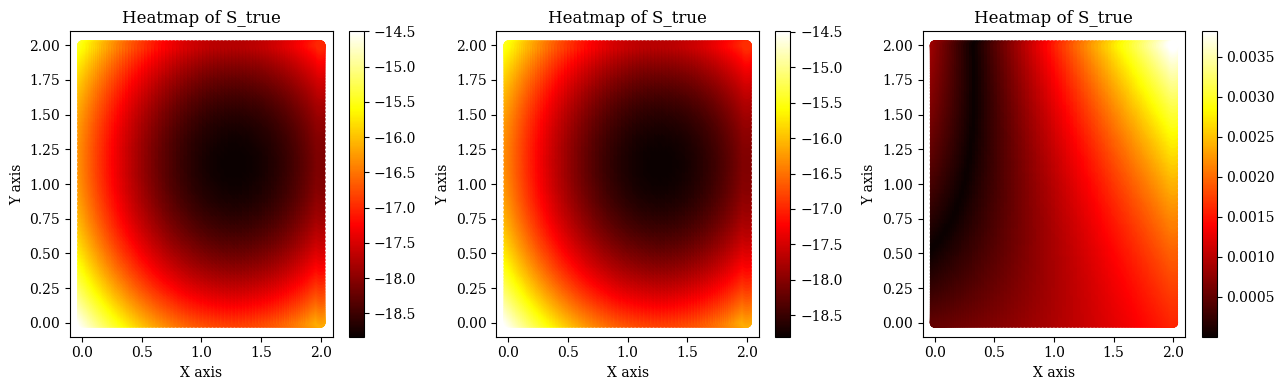

In [58]:
import matplotlib.pyplot as plt
S_2d = S_star_store[1]
#S_2d =(S_basis@s_star_store[-1]).reshape(100,100)
S_delta = S_delta_store[1]

plt.figure(figsize=(13, 4))

# First heatmap: S_true
plt.subplot(1, 3, 1)
plt.scatter(gauss_points[:, 0], gauss_points[:, 1], c=S_2d, cmap='hot')
plt.colorbar()
plt.title("Heatmap of S_true")
plt.xlabel("X axis")
plt.ylabel("Y axis")

# Second heatmap: S_delta
plt.subplot(1, 3, 2)
plt.scatter(gauss_points[:, 0], gauss_points[:, 1], c=S_delta, cmap='hot')
plt.colorbar()
plt.title("Heatmap of S_true")
plt.xlabel("X axis")
plt.ylabel("Y axis")

plt.subplot(1, 3, 3)
plt.scatter(gauss_points[:, 0], gauss_points[:, 1], c=np.abs((S_2d-S_delta)/S_2d), cmap='hot')
plt.colorbar()
plt.title("Heatmap of S_true")
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.tight_layout()
plt.show()


S_l_inf= 0.003588853658296187 S_L_2= 0.02372538928757754 S_l_2= 0.001342786220536783


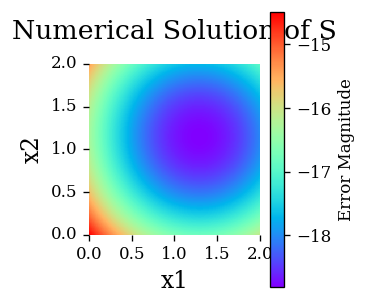

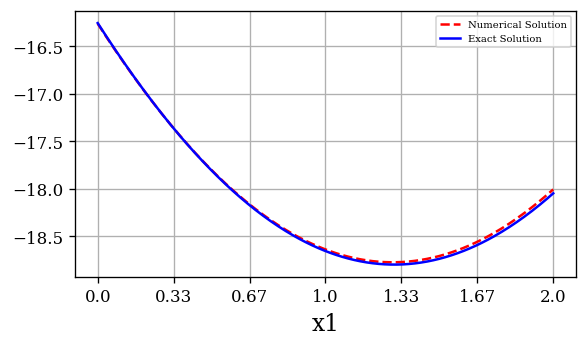

S_l_inf= 0.003679164185183933 S_L_2= 0.02477645886645901 S_l_2= 0.0014022736215754002


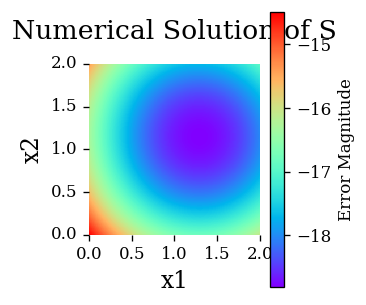

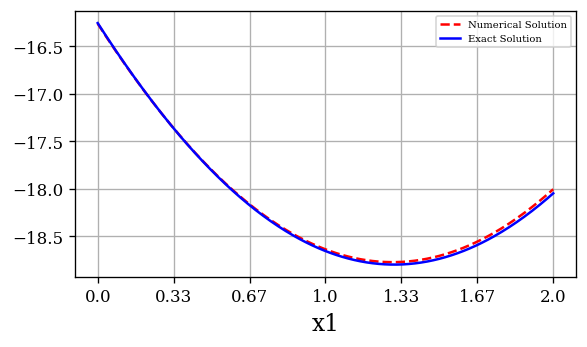

S_l_inf= 0.004567413001224206 S_L_2= 0.034913109988272926 S_l_2= 0.0019759778202199834


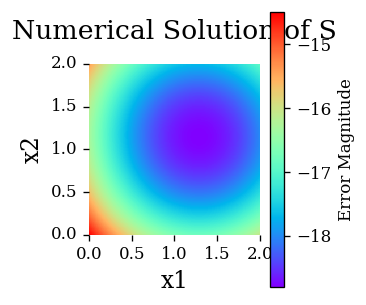

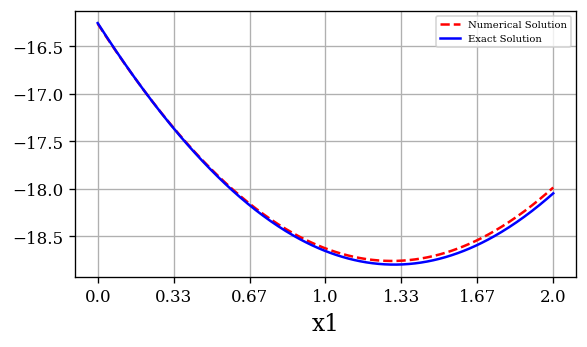

S_l_inf= 0.011769078614961834 S_L_2= 0.11136076352442073 S_l_2= 0.006302686837148853


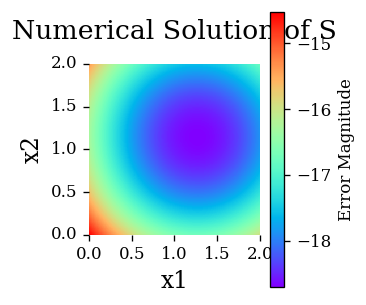

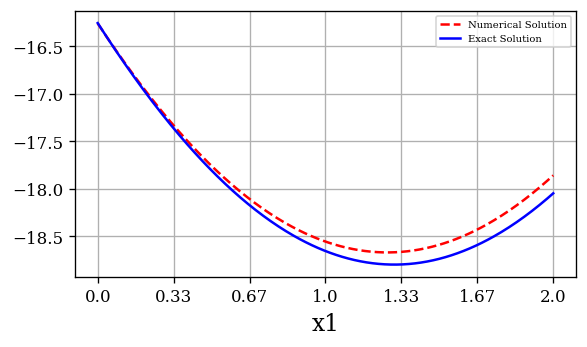

S_l_inf= 0.047315686564651904 S_L_2= 0.49607819476106246 S_l_2= 0.028076545179500888


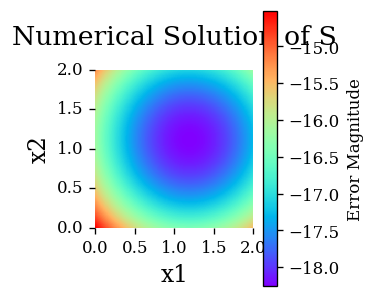

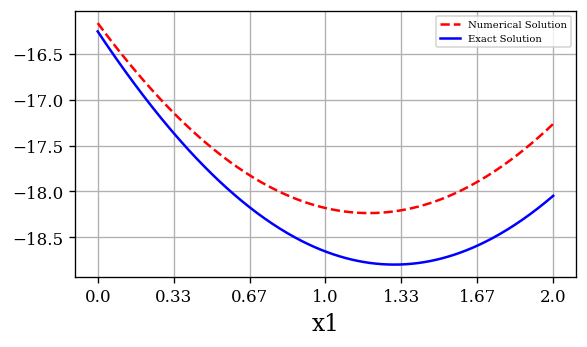

In [59]:
import error_general_2d
Qx=150
Qy=150
af="sin "
S_num_test_store=[]
S_star_test_store=[]
error_S_test=[]
for i in range(iter):
    S_num,S_star_test,S_l_inf,S_l_2=error_general_2d.test(model,M,Qx,Qy,s_delta_store[i],s_star,af,True,True,tau_x_min,tau_x_max,tau_y_min,tau_y_max,device)
    S_num_test_store.append(S_num)
    S_star_test_store.append(S_star_test)
    error_S_test.append(S_l_2)


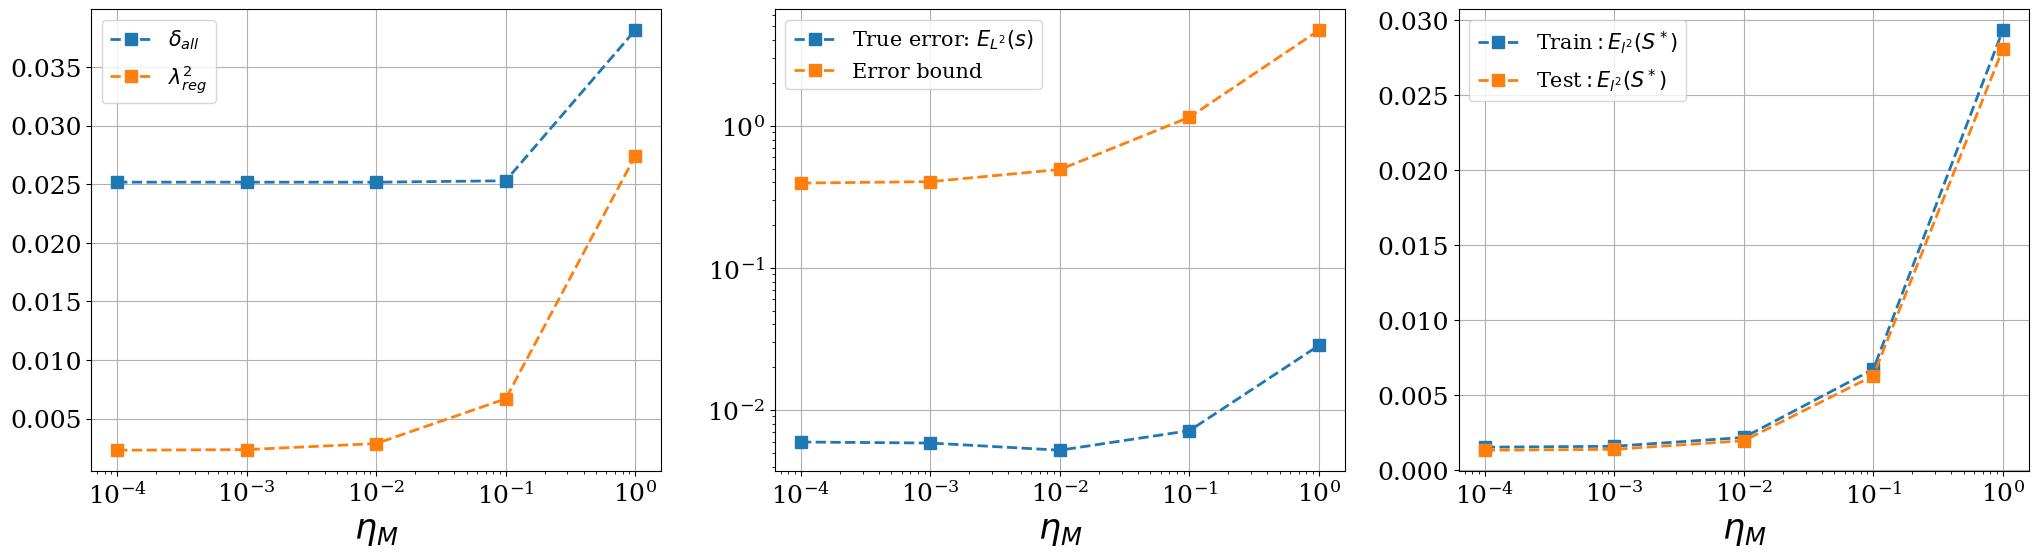

In [60]:
_, axes = plt.subplots(nrows=1, ncols=3, figsize=(25, 6))
axes = axes.reshape(-1)
grid = eta_M
axes[0].plot(eta_M, delta_store, label='$\delta_{all}$', marker='s', markersize=8, linestyle='--', linewidth=2)
axes[0].plot(eta_M, lambda_store, label='$\lambda_{reg}^2$', marker='s', markersize=8, linestyle='--', linewidth=2)
axes[0].set_xlabel(r"$\eta_M$", fontsize=25)
axes[0].tick_params(axis='both', labelsize=18)
axes[0].legend(fontsize=15)
axes[0].legend(fontsize=15)

axes[0].set_xscale('log')
axes[0].grid(True)  # Add grid lines

#plt.yscale('log') 

axes[1].plot(eta_M, error_s_store, label='True error: $ E_{L^2}(s)$', marker='s', markersize=8, linestyle='--', linewidth=2)
axes[1].plot(eta_M, bound_store, label='Error bound', marker='s', markersize=8, linestyle='--', linewidth=2)

axes[1].legend(fontsize=15)

axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel(r"$\eta_M$", fontsize=25)
axes[1].tick_params(axis='both', labelsize=18)
axes[1].legend(fontsize=15)
axes[1].grid(True)  

axes[2].plot(eta_M, np.array(error_S_store)/np.linalg.norm(np.array(S_star_store[-1])), label='Train$:E_{l^2}(S^*)$', marker='s', markersize=8, linestyle='--', linewidth=2)
axes[2].plot(eta_M, error_S_test, label='Test$:E_{l^2}(S^*)$', marker='s', markersize=8, linestyle='--', linewidth=2)
axes[2].set_xlabel(r"$\eta_M$", fontsize=25)
axes[2].tick_params(axis='both', labelsize=18)
axes[2].legend(fontsize=15)
axes[2].set_xscale('log')
axes[2].grid(True)  
plt.savefig("./results/theorem.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [61]:
np.save('./results/w.npy',w)
torch.save(model[0][0].state_dict(),"./results/model_3200.pth")
np.save("./results/S_basis.npy",S_basis)
np.save("./results/all_mat.npy",all_mat)
np.save("./results/all_mat_normalized.npy",all_mat_normalized)
np.save("./results/lambda_store.npy",lambda_store)
np.save("./results/error_s_store.npy",error_s_store)
np.save("./results/error_S_store.npy",error_S_store)
np.save("./results/bound_store.npy",bound_store)
np.save("./results/S_delta_store.npy",S_delta_store)
np.save("./results/S_star_store.npy",S_star_store)
np.save("./results/S_num_test_store.npy",S_num_test_store)
np.save("./results/S_star_test_store.npy",S_star_test_store)